In [1]:
import pandas as pd
from Data_PreProcess import preprocessing
from sklearn.model_selection import train_test_split

/tmp/ipykernel_6672/3428949533.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv("/home/Harsh/Documents/Coding/Rohit/ML Pipeline/bmw_cleaned.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [3]:
df.duplicated().sum()

0

In [4]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

In [5]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fueltype', 'tax',
       'mpg', 'enginesize'],
      dtype='object')

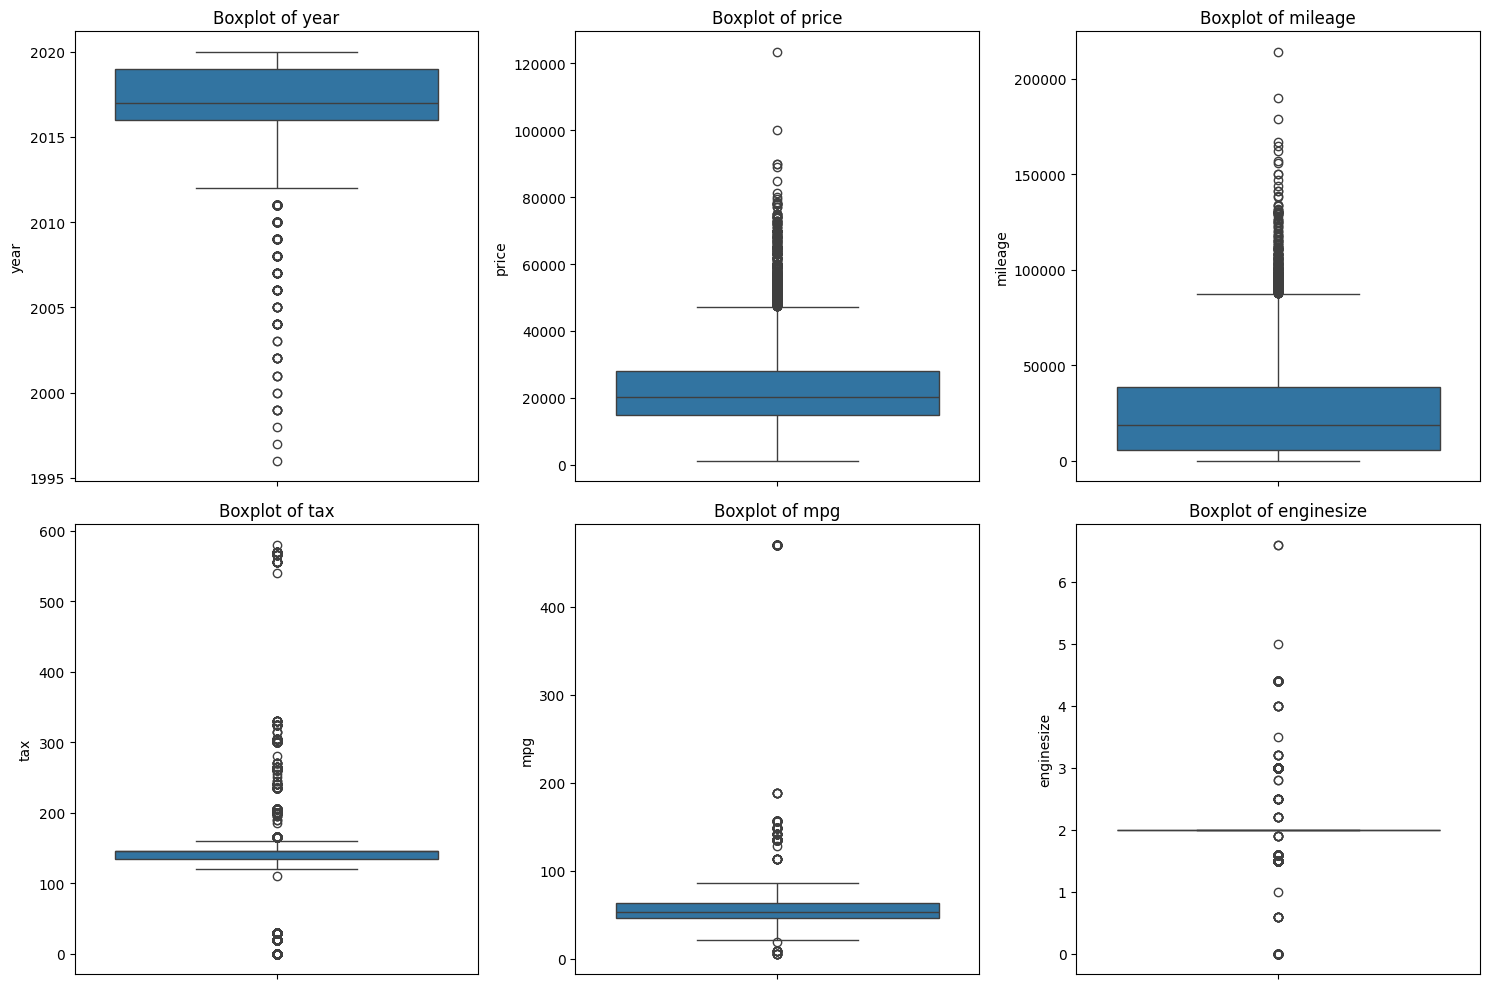

In [6]:
from matplotlib import pyplot as plt 
%matplotlib inline
import seaborn as sns
num_cols = ["year","price","mileage","tax","mpg","enginesize"]
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from scipy.stats import zscore 
def remove_outliers(df,threshold=3,target_col="price"):
    numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
    z_scores = np.abs(zscore(df[numeric_cols]))
    filter_df = df[(z_scores < threshold).all(axis=1)]
    return filter_df

data = remove_outliers(df)


In [8]:
data.head()

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


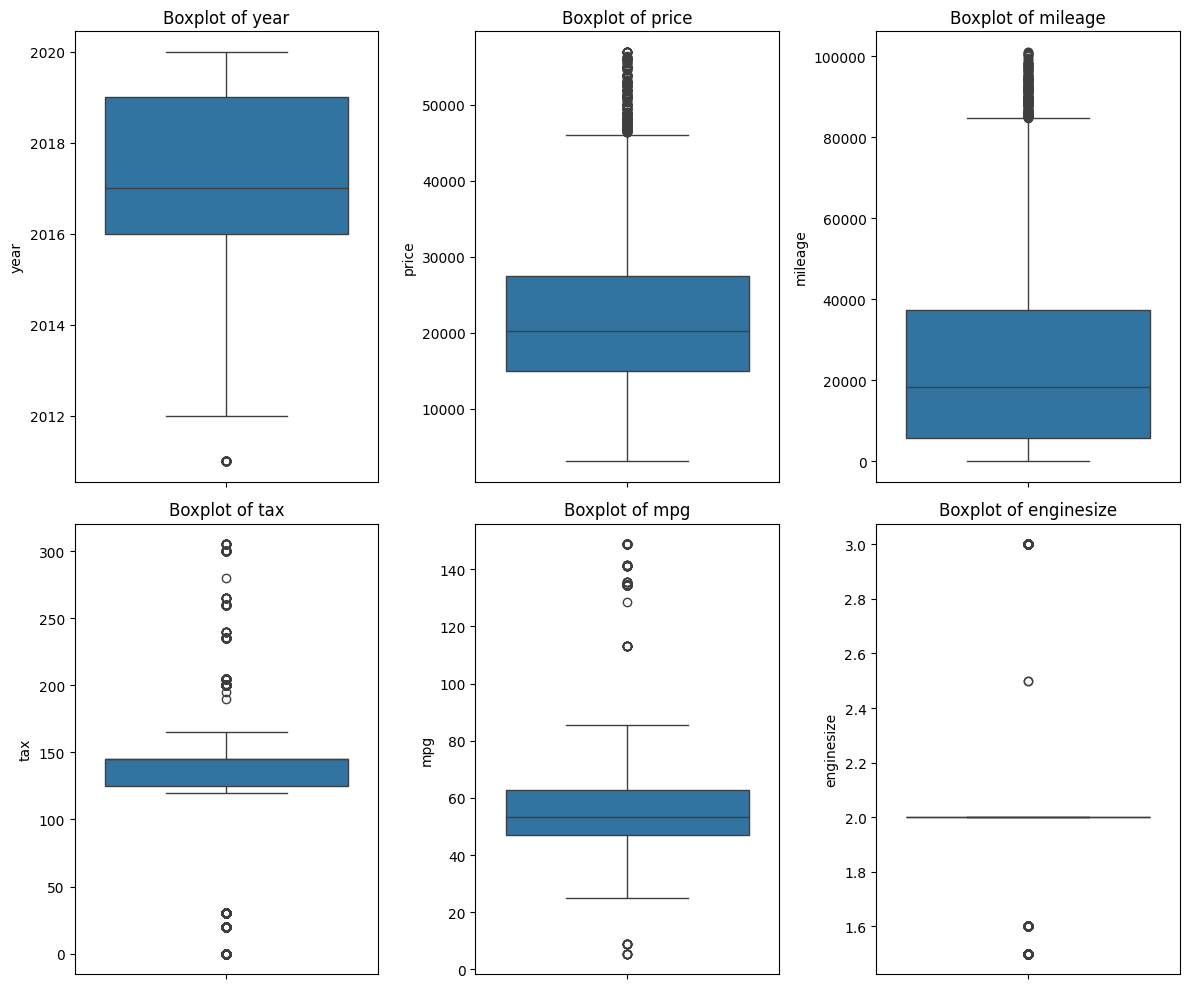

In [9]:
from matplotlib import pyplot as plt 
%matplotlib inline
import seaborn as sns
num_cols = ["year","price","mileage","tax","mpg","enginesize"]
plt.figure(figsize=(12,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=data[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


In [10]:
ppr = preprocessing()
X = data.drop("price", axis=1)
y = data["price"]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
print(x_train.columns)

Index(['model', 'year', 'transmission', 'mileage', 'fueltype', 'tax', 'mpg',
       'enginesize'],
      dtype='object')


In [13]:
data.head()

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [15]:
pipeline = Pipeline([
    ("ppr",preprocessing()),
    ("model",RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_leaf=2,min_samples_split=5,random_state=42))
])

In [16]:
pipeline.fit(x_train,y_train)

,steps,"[('ppr', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_predict = pipeline.predict(x_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error,  mean_absolute_error
rscore = r2_score(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
print("r2_Score: ",rscore)
print("Mean_SQuared_error: ",mse)
print("Mean_Absolute_Error: ",mae)

r2_Score:  0.9390103951601771
Mean_SQuared_error:  5840663.100309604
Mean_Absolute_Error:  1682.506536073461


In [19]:
from sklearn.model_selection import KFold
kfld = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline,x_train,y_train,cv=kfld,scoring='r2',n_jobs=-1)
print(scores)
print("Mean: ",scores.mean())
print("STD: ",scores.std())

[0.93378891 0.9305467  0.93675598 0.92505163 0.93284746]
Mean:  0.9317981361465861
STD:  0.003917293274686851


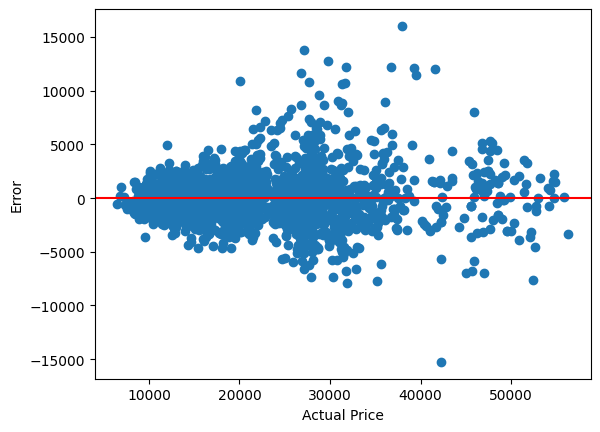

In [21]:
from matplotlib import pyplot as plt
%matplotlib inline
residuals = y_test - y_predict
plt.scatter(y_predict,residuals)
plt.axhline(0,color="red")
plt.xlabel("Actual Price")
plt.ylabel("Error")
plt.show()

In [22]:
meanprice = y_test.mean()
precentage_error = (1651.995053234816/meanprice) * 100
print(precentage_error)

7.365951768975424


In [23]:
import joblib 
joblib.dump(pipeline,"carmodel.pkl")

['carmodel.pkl']